In [2]:
# Question 1: Silhouette Score Analysis using K-Means++ 
# Tasks: 
# 1.Load the Mall Customers dataset and extract only the numeric 
#   features Annual Income (k$) and Spending Score (1-100). 
# 2.Apply K-Means++ clustering for values of k = 2 to 10. 
# 3.For each k, compute and record the average silhouette score. 
# 4.Plot the silhouette score vs. number of clusters (k). 
# 5.Identify the k value that gives the highest silhouette score 
# 6.Additionally, plot the silhouette distribution for k = 2, 4, and 6 


import pandas as pd
import numpy as np
data=pd.read_csv('MALL_Customers.csv.xls')

In [14]:
print("adding feture branch")

adding feture branch


In [1]:
print("Feature model update for collaborative workflow")

Feature model update for collaborative workflow


In [3]:
# annual_Income=data['Annual Income (k$)']
# spending_Score=data['Spending Score (1-100)']
X=data[['Annual Income (k$)','Spending Score (1-100)']].values

def initialize_centroids_kmeans_plus_plus(X, k):
    np.random.seed(42)
    centroids = []
    
    # Step 1: Choose one centroid randomly
    first_centroid = X[np.random.randint(0, X.shape[0])]
    centroids.append(first_centroid)
    
    # Step 2: Choose remaining k-1 centroids
    for _ in range(1, k):
        # Compute distance squared from each point to the nearest centroid
        distances = np.min(np.array([np.linalg.norm(X - c, axis=1)**2 for c in centroids]), axis=0)
        
        # Probability proportional to distance^2
        probs = distances / np.sum(distances)
        cumulative_probs = np.cumsum(probs)
        
        # Select next centroid based on weighted probability
        r = np.random.rand()
        for i, p in enumerate(cumulative_probs):
            if r < p:
                centroids.append(X[i])
                break
    return np.array(centroids)





In [4]:
# KMeans++ Helper function


def assign_clusters(X, centroids):
    # Compute distance between each point and each centroid
    distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
    # Assign points to the nearest centroid
    return np.argmin(distances, axis=0)

def update_centroids(X, labels, k):
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
    return new_centroids

def compute_wcss(X, labels, centroids):
    wcss = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        wcss += np.sum((cluster_points - centroids[i]) ** 2)
    return wcss


In [5]:
# KMeans++ Algo loop

def kmeans_plus_plus(X, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids_kmeans_plus_plus(X, k)
    
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        
        # Check for convergence
        if np.all(np.abs(new_centroids - centroids) < tol):
            break
        centroids = new_centroids
    
    wcss = compute_wcss(X, labels, centroids)
    return centroids, labels, wcss


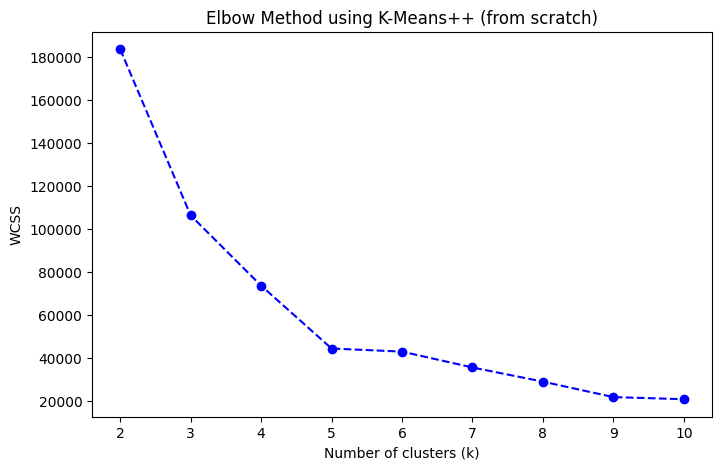

In [6]:
# Apply for k = 2 to 10 (Elbow Method)

import matplotlib.pyplot as plt

wcss_values = []
K = range(2, 11)

for k in K:
    centroids, labels, wcss = kmeans_plus_plus(X, k)
    wcss_values.append(wcss)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K, wcss_values, marker='o', linestyle='--', color='b')
plt.title('Elbow Method using K-Means++ (from scratch)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()


In [7]:
# Silhouette Score Function (from scratch)

def silhouette_score_manual(X, labels):
    n = X.shape[0]
    unique_clusters = np.unique(labels)
    k = len(unique_clusters)
    sil_scores = np.zeros(n)

    for i in range(n):
        same_cluster = labels == labels[i]
        other_clusters = [c for c in unique_clusters if c != labels[i]]
        
        # a(i): mean intra-cluster distance
        a = np.mean([np.linalg.norm(X[i] - X[j]) for j in range(n) if same_cluster[j] and i != j])
        if np.isnan(a):  # handle single-point cluster
            a = 0

        # b(i): smallest mean distance to another cluster
        b = np.inf
        for c in other_clusters:
            cluster_points = X[labels == c]
            if len(cluster_points) > 0:
                dist = np.mean(np.linalg.norm(X[i] - cluster_points, axis=1))
                b = min(b, dist)
        
        sil_scores[i] = (b - a) / max(a, b)
    
    return np.mean(sil_scores)


In [8]:
# Compute Average Silhouette Scores for k = 2 → 10

silhouette_values = []

for k in range(2, 11):
    centroids, labels, wcss = kmeans_plus_plus(X, k)
    score = silhouette_score_manual(X, labels)
    silhouette_values.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")


k = 2, Silhouette Score = 0.3956
k = 3, Silhouette Score = 0.4676
k = 4, Silhouette Score = 0.4932
k = 5, Silhouette Score = 0.5539
k = 6, Silhouette Score = 0.3872
k = 7, Silhouette Score = 0.4557
k = 8, Silhouette Score = 0.4558
k = 9, Silhouette Score = 0.4565
k = 10, Silhouette Score = 0.4524


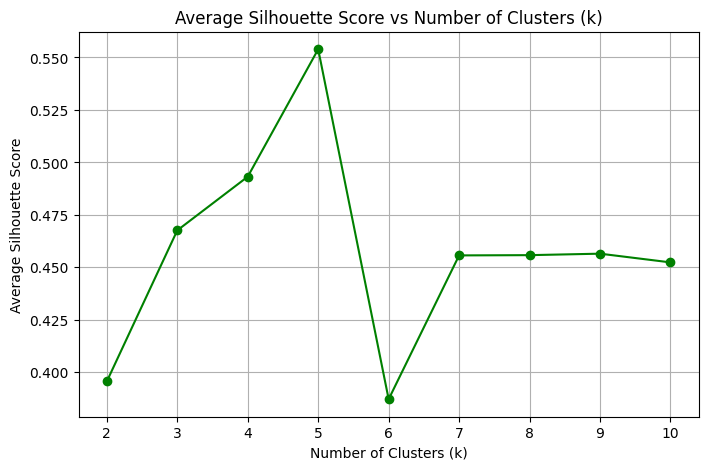

 Best number of clusters (highest silhouette score): k = 5


In [9]:
# Plot Silhouette Score vs. k

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_values, marker='o', color='green')
plt.title('Average Silhouette Score vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.grid(True)
plt.show()

# Identify best k
best_k = range(2, 11)[np.argmax(silhouette_values)]
print(f" Best number of clusters (highest silhouette score): k = {best_k}")


In [10]:
# Plot Silhouette Distribution for k = 2, 4, and 6

def plot_silhouette_distribution(X, labels, k):
    from matplotlib import cm
    n_clusters = len(np.unique(labels))
    y_lower = 10
    fig, ax = plt.subplots(figsize=(7,5))
    colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
    
    silhouette_vals = []
    for i in range(len(X)):
        same_cluster = labels == labels[i]
        other_clusters = [c for c in np.unique(labels) if c != labels[i]]
        
        a = np.mean([np.linalg.norm(X[i] - X[j]) for j in range(len(X)) if same_cluster[j] and i != j])
        if np.isnan(a):
            a = 0
        b = np.inf
        for c in other_clusters:
            cluster_points = X[labels == c]
            if len(cluster_points) > 0:
                dist = np.mean(np.linalg.norm(X[i] - cluster_points, axis=1))
                b = min(b, dist)
        silhouette_vals.append((b - a) / max(a, b))
    silhouette_vals = np.array(silhouette_vals)
    
    for i in range(k):
        cluster_sil_vals = silhouette_vals[labels == i]
        cluster_sil_vals.sort()
        size_cluster = cluster_sil_vals.shape[0]
        y_upper = y_lower + size_cluster
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_sil_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        y_lower = y_upper + 10  # for spacing between clusters
    
    ax.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    ax.set_title(f"Silhouette Plot for k = {k}")
    ax.set_xlabel("Silhouette Coefficient Values")
    ax.set_ylabel("Cluster Label")
    plt.show()




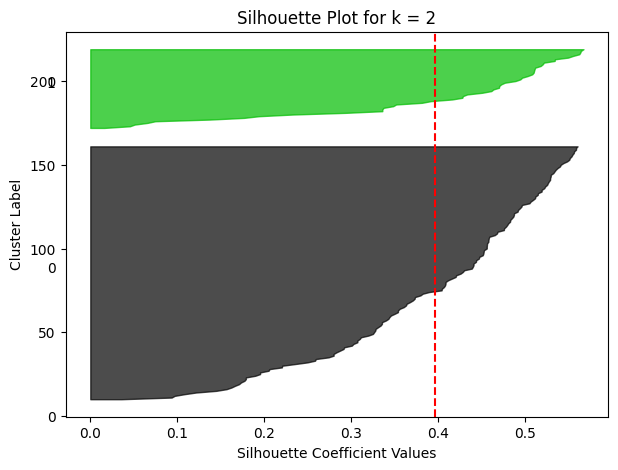

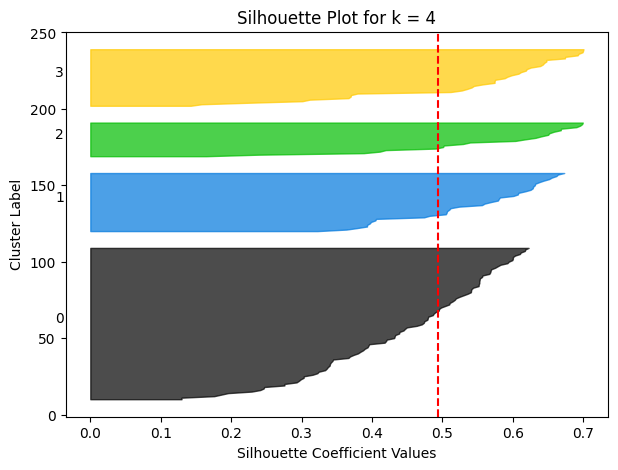

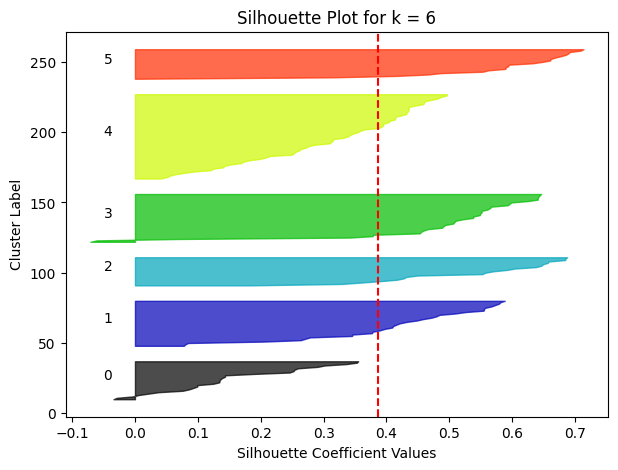

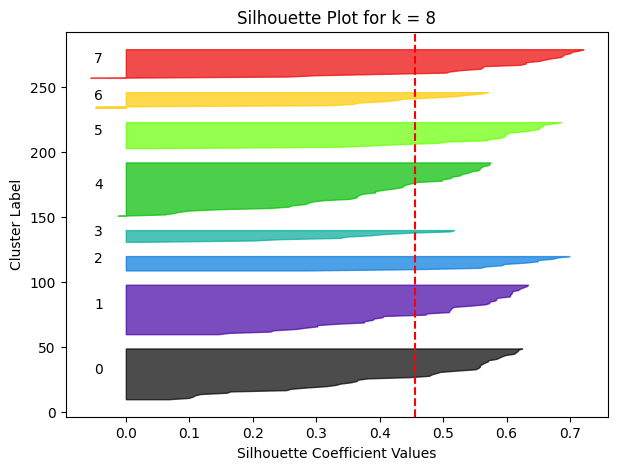

In [11]:
for k in [2, 4, 6,8]:
    centroids, labels, _ = kmeans_plus_plus(X, k)
    plot_silhouette_distribution(X, labels, k)


In [12]:
# Question 2: Elbow Method for Optimal Cluster Selection Tasks: 
# 1.Apply standard K-Means clustering for k = 1 to 12. 
# 2.For each k, compute the Within-Cluster Sum of Squares (WCSS). 
# 3.Plot the Elbow Curve (WCSS vs. k). 
# 4.Identify the “elbow point” visually where the rate of decrease in 
# WCSS slows down. 
# 5. Compare whether the optimal cluster number obtained from the 
# Elbow method aligns with that from the silhouette analysis in Question 1. 

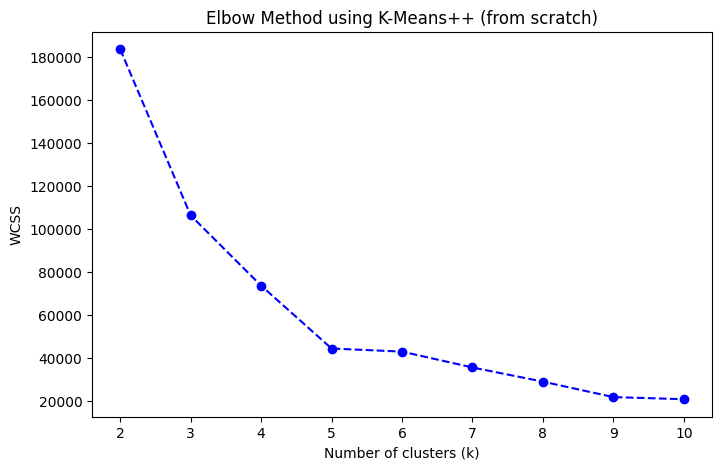

In [13]:

wcss_values = []
K = range(2, 11)

for k in K:
    centroids, labels, wcss = kmeans_plus_plus(X, k)
    wcss_values.append(wcss)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K, wcss_values, marker='o', linestyle='--', color='b')
plt.title('Elbow Method using K-Means++ (from scratch)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()